## Book Reviews Sentiment Analysis 📚

### Project Overview 🔍

This project analyzes sentiment in book reviews using two different models:

1. **VADER (Valence Aware Dictionary and Sentiment Reasoner)**: A rule-based sentiment analysis tool specifically designed for social media content and short texts.

2. **Transformer-based model (DistilBERT)**: A pre-trained transformer model fine-tuned for sentiment classification.

### Methodology 📋

The analysis pipeline involves:

1. **Data Loading**: Reading book reviews from a CSV file containing review text and ratings
2. **Text Preprocessing**: Converting text to lowercase and removing special characters
3. **Analysis Approach**:
   - VADER analysis categorizes sentiment as positive, neutral, or negative
   - Transformer model classifies text as positive or negative and calculates an difference of sentiment score

### Visualization 📈

Results are visualized using bar charts showing:
- Distribution of sentiment categories from VADER analysis
- Counts of positive vs negative classifications from the transformer model
- difference of sentiment score (positive count minus negative count)

### Purpose ✨

This project demonstrates how different sentiment analysis approaches can yield complementary insights. The rule-based VADER provides nuanced categorization with a neutral class, while the transformer model leverages deep learning to provide binary classification with potentially higher accuracy on complex expressions.

The comparative analysis helps identify strengths and limitations of each approach when applied to book review data.

<br>



#### Import Libary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

c:\Users\armys\OneDrive\Desktop\SentimentAnalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Function

In [2]:
def analyze_vader_sentiment(data, text_column='reviewText'):
    """
    Analyze sentiment using VADER and create a new column with sentiment labels.
    
    Parameters:
    -----------
    data : pandas DataFrame
        DataFrame containing text to analyze
    text_column : str
        Name of the column containing text to analyze
    
    Returns:
    --------
    data : pandas DataFrame
        Original DataFrame with additional columns for
        sentiment scores and sentiment labels
    """
    
    vader_sentiment = SentimentIntensityAnalyzer()
    
    # Apply VADER and get compound score
    data['vader_sentiment_score'] = data[text_column].apply(
        lambda review: vader_sentiment.polarity_scores(review)['compound']
    )
    
    # Create sentiment labels based on compound score
    bins = [-1, -0.1, 0.1, 1]
    names = ['negative', 'neutral', 'positive']
    data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)
    data = pd.DataFrame(data)
    
    # Creating DataFrame
    display(pd.DataFrame(data['vader_sentiment_label'].value_counts()))
    display(data.head(5))
    
    # Create plot with correct color mapping
    plt.figure(figsize=(10, 6))
    
    # Get the counts
    sentiment_counts = data['vader_sentiment_label'].value_counts()
    
    # Create a color map to ensure colors match with their labels
    color_map = {
        'positive': '#58d68d',  
        'neutral': '#5dade2',   
        'negative': '#e74c3c'   
    }
    
    # Map the colors to the index of the value_counts
    colors = [color_map[label] for label in sentiment_counts.index]
    
    # Plot with specific colors
    sentiment_counts.plot.bar(color=colors)
    
    plt.xlabel('vader_sentiment_label')
    plt.xticks(rotation=0)
    plt.title('VADER Sentiment Analysis Results')
    plt.tight_layout()
    plt.show()
    
    return data

In [3]:
def transformer_sentiment(data, text_column='reviewText'):
    """
    Analyze sentiment using transformer model and create new columns with sentiment labels.
    
    Parameters:
    -----------
    data : pandas DataFrame
        DataFrame containing text to analyze
    text_column : str
        Name of the column containing text to analyze
    
    Returns:
    --------
    data : pandas DataFrame
        Original DataFrame with additional columns for
        sentiment scores and sentiment labels
    """
    # Transformer model
    sentiment_pipeline = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")
    
    # Process text data and store results
    results = sentiment_pipeline(data[text_column].tolist())
    
    # Add transformer results to dataframe
    data['transformer_sentiment_label'] = [r['label'] for r in results]
    data['transformer_sentiment_score'] = [r['score'] for r in results]
    
    # Standardize labels to match VADER (POSITIVE -> positive, NEGATIVE -> negative)
    data['transformer_sentiment_label'] = data['transformer_sentiment_label'].str.lower()
    
    # Count occurrences
    sentiment_counts = data['transformer_sentiment_label'].value_counts()
    pos_count = sentiment_counts.get('positive', 0)
    neg_count = sentiment_counts.get('negative', 0)
    difference = abs(pos_count - neg_count)
    
    # Display dataframe info
    display(pd.DataFrame(data['transformer_sentiment_label'].value_counts()))
    display(data.head(5))
    
    # Create plot
    plt.figure(figsize=(11, 8))
    categories = ['positive', 'negative', 'difference']
    values = [pos_count, neg_count, difference]
    
    # Create a color mapping dictionary to ensure consistency
    color_map = {
        'positive': '#58d68d',  
        'negative': '#e74c3c',  
        'difference': '#e7a92d'
    }
    
    # Map the colors according to categories
    colors = [color_map[category] for category in categories]
    
    bars = plt.bar(categories, values, color=colors)
    
    # Add labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height}', 
                ha='center', va='bottom', fontweight='bold')
    
    plt.title('Transformer Sentiment Analysis Results')
    plt.ylabel('Frequency') 
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return data

<br>

#### Fetch Data

In [ ]:
FILE_PATH = r'book_reviews_sample.csv' # replace with your csv file path
DATA = pd.read_csv(FILE_PATH)
display(DATA.head(5))

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1


<br>

#### Frequency of Rating

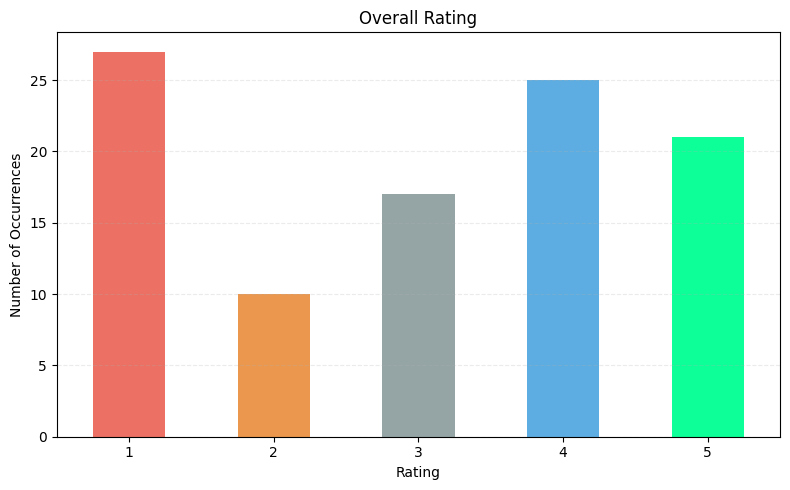

In [5]:
# 1. Get the value counts for the 'rating' column
rating_counts = DATA['rating'].value_counts()

# 2. Sort the counts by the rating value (the index)
rating_counts_sorted = rating_counts.sort_index()

# 3. Create the bar plot
plt.figure(figsize=(8, 5))  # You can adjust the figure size if needed
rating_counts_sorted.plot.bar(color=['#ec7063', '#eb984e', '#95a5a6', '#5dade2', '#0dff98'])
plt.title('Overall Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Occurrences')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

<br>

#### Text - Processing & Data Wrangling

In [6]:
# Clean the data first
DATA['reviewText_clean'] = DATA['reviewText'].str.lower()
DATA['reviewText_clean'] = DATA.apply(lambda x: re.sub(r"[^\w\s]", "", x['reviewText_clean']), axis=1)

<br>

<br>

#### Transformer Sentiment Analysis

This function uses a pre-trained DistilBERT model to classify book reviews as either POSITIVE or NEGATIVE. The process:

1. Loads reviews through the pipeline configured with "distilbert-base-uncased-finetuned-sst-2-english"
2. Counts positive and negative classifications
3. Calculates difference of sentiment (positive_count - negative_count)
4. Generates a bar chart with color-coded results
5. Returns counts for further analysis

All PyTorch model weights were used when initializing TFDistilBertForSequenceClassification.

All the weights of TFDistilBertForSequenceClassification were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertForSequenceClassification for predictions without further training.


,count
transformer_sentiment_label,
positive,58
negative,42


,index,reviewText,rating,reviewText_clean,transformer_sentiment_label,transformer_sentiment_score
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,positive,0.999620
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,positive,0.999873
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,negative,0.999712
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,positive,0.988936
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,negative,0.999435


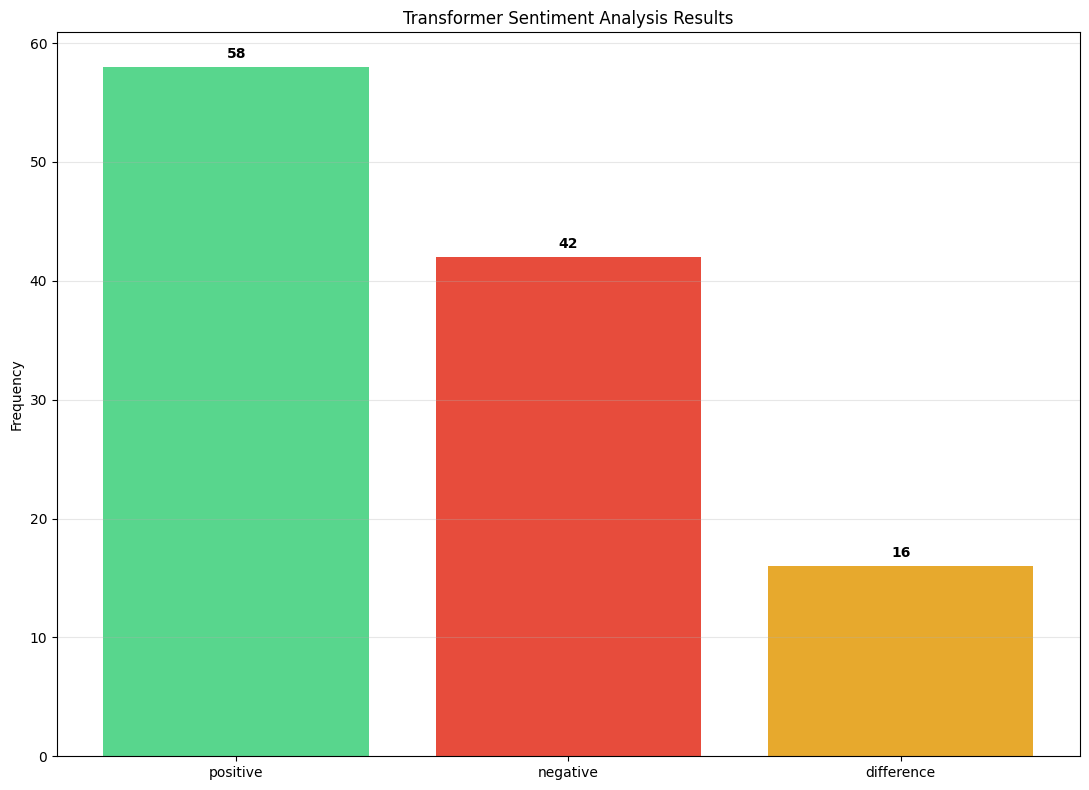

In [7]:
transformer_result = transformer_sentiment(DATA, text_column='reviewText')

<br>

#### VADER Sentiment Analysis 

This function uses VADER (Valence Aware Dictionary and Sentiment Reasoner), a rule-based sentiment analyzer specifically attuned to social media content. The process:

1. Cleans input text (lowercase, special character removal)
2. Applies SentimentIntensityAnalyzer to extract compound polarity scores
3. Categorizes text into negative (-1 to -0.1), neutral (-0.1 to 0.1), or positive (0.1 to 1)
4. Visualizes results with a color-coded bar chart (red for negative, blue for neutral, green for positive)
5. Returns the enhanced DataFrame with sentiment scores and labels

,count
vader_sentiment_label,
positive,71
negative,19
neutral,10


,index,reviewText,rating,reviewText_clean,transformer_sentiment_label,transformer_sentiment_score,vader_sentiment_score,vader_sentiment_label
0,11494,Clean and funny. A bit busy with all the diffe...,3,clean and funny a bit busy with all the differ...,positive,0.999620,0.7684,positive
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4,alex a sexy hot cop and the phd candidate what...,positive,0.999873,0.9325,positive
2,1463,Good thing that this is a free story. I read i...,1,good thing that this is a free story i read it...,negative,0.999712,0.6740,positive
3,10342,"Action, action, action! Equipment keeps gettin...",4,action action action equipment keeps getting b...,positive,0.988936,0.6948,positive
4,5256,this was hands down the worse book i have ever...,1,this was hands down the worse book i have ever...,negative,0.999435,-0.4767,negative


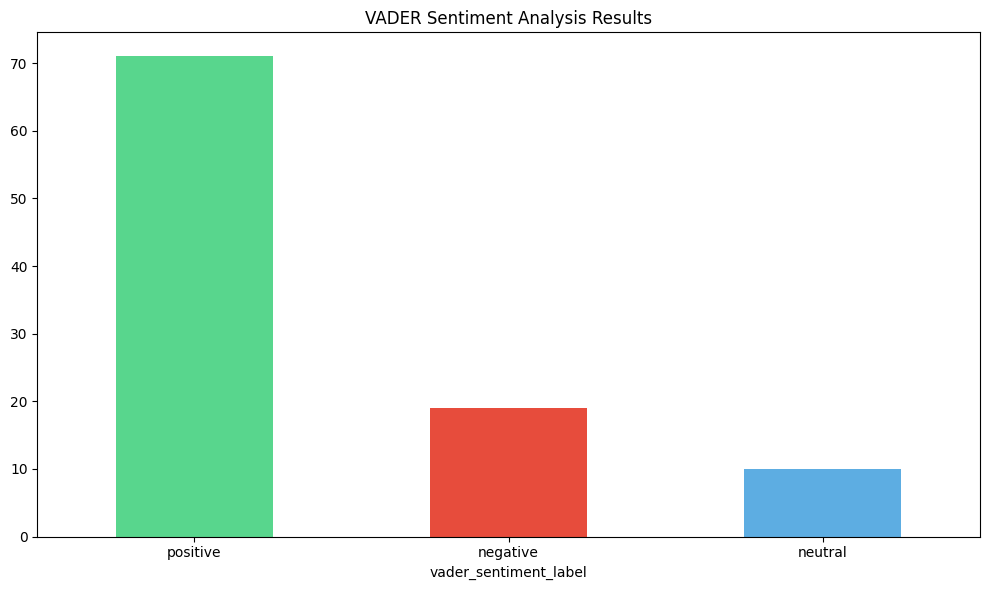

In [8]:
vader_result = analyze_vader_sentiment(DATA, text_column='reviewText')